# Testing of PTIR Tools Library
**High-Dimensional Image Stacks**

## Set Up Python Environment

### Other Libraries

In [1]:
### required libraries
import sys
import os
import glob

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import pprint as pp

### PTIR Tools Library
- add search path
- import

In [2]:
### ### add src directory to library paths
### path = os.path.abspath(os.path.join('.', 'src'))
### if path not in sys.path:
###     sys.path.append(path)
### del path

### Import PTIR Tools library to run tests
import ptirtools as ptir
from ptirtools import debug

## Define Execution Parameters
- working directories

In [3]:
INPUT_DIRECTORY = "./ptirfiles"
OUTPUT_DIRECTORY = "./output"

In [4]:
### find ptir files
ptirfilenames = glob.glob(f"{INPUT_DIRECTORY}/*.ptir")
print("PTIR files for testing:\n" + "\n".join(ptirfilenames))

PTIR files for testing:
./ptirfiles/251212 A platensis FLPTIR.ptir
./ptirfiles/251201 index.ptir
./ptirfiles/251201 bead_dimer 30kHz.ptir


## Test the Library

In [5]:
### set debug level to show everything
ptir.misc.debugging.suppress_debug_levels('success')

debugging.py in line 131:	Debug Levels:
                          	<DebugLevel  1 ''  | traceback: 0 | active>
                          	<DebugLevel  2 'Debug Info'  | traceback: 1 | active>
                          	<DebugLevel  3 'Trace'  | traceback: -1 | active>
                          	<DebugLevel  4 'Success'  | traceback: 0 | suppressed>
                          	<DebugLevel  5 'Info'  | traceback: 1 | active>
                          	<DebugLevel  6 'Warning'  | traceback: 1 | active>
                          	<DebugLevel  7 'Error'  | traceback: 1 | active>
                          	<DebugLevel  8 'Critical'  | traceback: -1 | active>
                          	<DebugLevel  3 'Trace2'  | traceback: 2 | active>
                          	<DebugLevel  3 'Trace3'  | traceback: 3 | active>
                          	<DebugLevel  3 'Trace4'  | traceback: 4 | active>
                          	<DebugLevel  3 'Trace5'  | traceback: 5 | active>
                          	<Debu

### Read PTIR Files and List Contents

In [6]:
### read all files into a single file object
PTIRFILE = ptir.PTIRFile()
for ifn in ptirfilenames:
    PTIRFILE.safe_load(ifn)

base.py in line 55:	WARNING: measurement has no attribute 'Timestamp':
                    	- uuid: 1389d90a-b4bc-4b33-a66d-8cc52f5a7f54
                    	- TYPE: CameraImage
                    	- label: Color Image 1
base.py in line 73:	Measurement '1389d90a-b4bc-4b33-a66d-8cc52f5a7f54' is missing some basic attributes. Data shape is (512, 512, 4)
metadata.py in line 17:	WARNING: configuration has no attribute 'TopFocus':
                        	- ImageHeight: [66.56]
                        	- ImageWidth: [66.56]
                        	- Label: b'Color Image 1'
                        	- Notes: b'[Green] Image: 1660 cm\xe2\x81\xbb\xc2\xb9 Min: 0 Max: 1084, [Blue] Image: 1200 cm\xe2\x81\xbb\xc2\xb9 Min: 0 Max: 811, [Red] Image: 1080 cm\xe2\x81\xbb\xc2\xb9 Min: 0 Max: 864'
                        	- PixelFormat: b'Bgra32'
                        	- PositionX: [-838.2999]
                        	- PositionY: [1847.1]
                        	- TYPE: b'CameraImage'
metadata.py in

In [7]:
print(f"PTIR files contain...\n" + PTIRFILE.summary())

PTIR files contain...
- 4 backgrounds of type <class 'ptirtools.measurements.base.OPTIRSpectrum'>
- 6306 measurements of type <class 'ptirtools.measurements.base.OPTIRImage'>
- 18 measurements of type <class 'ptirtools.measurements.base.FLPTIRImage'>
- 99 measurements of type <class 'ptirtools.measurements.base.OPTIRSpectrum'>
- 6 measurements of type <class 'ptirtools.measurements.base.CameraImage'>
- 9 measurements of type <class 'ptirtools.measurements.base.FluorescenceImage'>


### Assemble Higher-Dimensional Datasets

#### Build Structured Trees of Measurement UUIDs

In [8]:
filters = (
    ptir.measurements.filter.MatchValue("configuration.ir_pulse_rate", 30_000),
    ptir.measurements.filter.MatchValue("optir_channel.harmonic_order", 1),
)
groups = [
    "lateral_domain",
    "wavenumber",
    "vertical_position.top_focus",
    "optir_channel.signal_component",
]

In [11]:
filtered_images = PTIRFILE.filter(PTIRFILE.optir_images, *filters)
print(f"{len(filtered_images)}/{len(PTIRFILE.optir_images)}")

4182/6306


In [12]:
uuidtree = PTIRFILE.separate_measurements_by_attributes(filtered_images, *groups)
ld = list(uuidtree.keys())[0]
pp.pprint(uuidtree[ld])

{np.float32(1150.0): {np.float32(1332.6): {<ModulatedSignalComponent.PHAS: 70>: ['dc33edd6-9d8a-45ad-b531-a8fd2e57adfe'],
                                           <ModulatedSignalComponent.AMPL: 73>: ['897533f8-3b88-4706-8d9d-58ceb90da8e0']},
                      np.float32(1332.95): {<ModulatedSignalComponent.PHAS: 70>: ['5502cce6-753a-4227-aa88-aa6b34b76564'],
                                            <ModulatedSignalComponent.AMPL: 73>: ['11c26ae6-5696-4e3f-ae48-0f0770bd627b']},
                      np.float32(1334.15): {<ModulatedSignalComponent.PHAS: 70>: ['fd1c8872-7b94-4af7-ad6f-78ac92bc6f83'],
                                            <ModulatedSignalComponent.AMPL: 73>: ['2c86acad-c313-4019-92ce-70795f2fa4d4']},
                      np.float32(1334.55): {<ModulatedSignalComponent.PHAS: 70>: ['78f4aede-1619-45b3-979e-3f29ba64ee20'],
                                            <ModulatedSignalComponent.AMPL: 73>: ['3c6a09c2-6d55-4d1f-8a4b-476a82f153f7']},
              

In [ ]:
# filtered_uuids = PTIRFILE.filter(PTIRFILE.optir_spectra, { 'optir_channel.harmonic_order' : 1 })
# 
# print(f"{len(filtered_uuids)}/{len(PTIRFILE.optir_spectra)}")
# for uuid in filtered_uuids:
#     spectrum:ptir.measurements.OPTIRSpectrum = PTIRFILE[uuid]
#     print(f"{spectrum.TYPE} '{uuid}'")
#     #print(f"    {spectrum.configuration}")
#     #print(f"    {spectrum.lateral_position}")
#     #print(f"    {spectrum.vertical_position}")
#     print(f"    {spectrum.optir_channel}")

### Test Assemble Complex Measurements

In [ ]:
complex_OPTIR_spectra = ptir.datasets.ComplexOPTIRMeasurementContainer(
    PTIRFILE,
    sort_spec = [ 'timestamp', 'lateral_domain' ],
    filter_spec = ( 
        ptir.measurements.filter.MatchValue('TYPE', "OPTIRSpectrum"),
        ptir.measurements.filter.MatchValue('optir_channel.harmonic_order', 1),
    )
)

datasets.py in line 120:	No ideally well-defined complex representations are available.
datasets.py in line 143:	No well-defined complex representations are available.
datasets.py in line 148:	WARNING: Using amplitude as real part; setting imaginary part to zero:
                         	OPTIRSpectrum '7f55157f-7cf8-4389-9d44-97618c61c258'
                         	OPTIR Measurement Configuration:
                         	        MIRcat QT laser, Counterpropagating beam path (50X(2) objective), Standard detector @ 10X gain
                         	        100000000.0Hz x 9.999999506879345e-17s -> duty cycle: 0.010499999858438969
                         	        532 nm probe laser @ 532.0nm, 0.10000000149011612x power
                         	Lateral Position: x=20635.5µm, y=46435.8515625µm
                         	OPTIR Vertical Position: top: 978.25µm, bottom: 24387.119140625µm
                         	OPTIR Measurement Channel 'O-PTIR', Data Signal: '//ZI/*/DEMODS/0/R, Units: 

In [ ]:
complex_OPTIR_images = ptir.datasets.ComplexOPTIRMeasurementContainer(
    PTIRFILE,
    sort_spec = [ 'lateral_domain', 'vertical_position.top_focus', 'wavenumber' ],
    filter_spec = { 
        'TYPE' : "OPTIRImage" ,
        'configuration.ir_pulse_rate' : 30_000 ,
        'optir_channel.harmonic_order' : 1 ,
    }
)

datasets.py in line 120:	No ideally well-defined complex representations are available.
datasets.py in line 143:	No well-defined complex representations are available.
datasets.py in line 159:	WARNING: Only phase information available. Setting amplitude to one:
                         	OPTIRImage '08ddf9a4-5305-4b2c-9afc-55e63b60012b'
                         	OPTIR Measurement Configuration:
                         	        MIRcat QT laser, Counterpropagating beam path (50X(2) objective), Standard detector @ 20X gain
                         	        30000.0Hz x 3.999999975690116e-08s -> duty cycle: 0.0010000000474974513
                         	        532 nm probe laser @ 532.0nm, 0.029999999329447746x power
                         	<<class 'ptirtools.domains.domains.RasterizedLateralDomain'>, 161, 91, 172.7, 7073.25, 16.0, 9.0>
                         	OPTIR Vertical Position: top: 1361.6500244140625µm, bottom: 24394.890625µm
                         	OPTIR Measurement Channel

In [ ]:
complex_OPTIR_spectra.parameters, complex_OPTIR_images.parameters

(('timestamp', 'lateral_domain'),
 ('lateral_domain', 'vertical_position.top_focus', 'wavenumber'))

In [ ]:
complex_OPTIR_spectra = ptir.datasets.ComplexOPTIRSpectraContainer(
    PTIRFILE,
    sort_spec = [ 'timestamp' ],
    filter_spec = { 'optir_channel.harmonic_order' : 1 }
)

datasets.py in line 324:	No ideally well-defined complex representations are available.
datasets.py in line 347:	No well-defined complex representations are available.
datasets.py in line 352:	WARNING: Using amplitude as real part; setting imaginary part to zero:
                         	OPTIRSpectrum '2ebdf24f-124c-46bd-bf56-0ffb5df8b82b'
                         	OPTIR Measurement Configuration:
                         	        MIRcat QT laser, Counterpropagating beam path (50X(2) objective), Standard detector @ 10X gain
                         	        100000000.0Hz x 9.999999506879345e-17s -> duty cycle: 0.010499999858438969
                         	        532 nm probe laser @ 532.0nm, 0.10000000149011612x power
                         	Lateral Position: x=20635.5µm, y=46435.8515625µm
                         	OPTIR Vertical Position: top: 992.9500122070312µm, bottom: 24552.919921875µm
                         	OPTIR Measurement Channel 'O-PTIR', Data Signal: '//ZI/*/DEMODS/0

In [ ]:
complex_OPTIR_spectra.parameter_values

[[np.int64(639001711233959848)],
 [np.int64(639011417480546234)],
 [np.int64(639002856059048696)],
 [np.int64(639011418487034131)],
 [np.int64(639004784744379330)],
 [np.int64(639004786657603993)],
 [np.int64(639004787353908111)],
 [np.int64(639004785437692887)],
 [np.int64(639004787702924213)],
 [np.int64(639004784916773505)],
 [np.int64(639002860303963439)],
 [np.int64(639004787005325412)],
 [np.int64(639004787528959422)],
 [np.int64(639004787180454821)],
 [np.int64(639011419915944817)],
 [np.int64(639002852538067226)],
 [np.int64(639001702809502457)],
 [np.int64(639011407461741052)],
 [np.int64(639002864122959780)],
 [np.int64(639004786306489173)],
 [np.int64(639004786833080817)],
 [np.int64(639004788047882294)],
 [np.int64(639002855513423147)],
 [np.int64(639004785784149943)],
 [np.int64(639001702143318400)],
 [np.int64(639004785611335193)],
 [np.int64(639004786131009481)],
 [np.int64(639004787875183356)],
 [np.int64(639004786484603846)],
 [np.int64(639002854120042232)],
 [np.int64

In [ ]:
complex_OPTIR_spectra.spectra

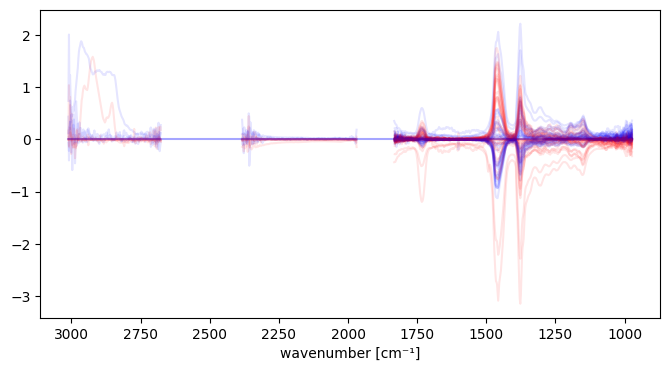

In [ ]:
fig = plt.figure(figsize=(8,4))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0])

for param_values,spectrum in zip(complex_OPTIR_spectra.parameter_values, complex_OPTIR_spectra.spectra):
    ax.plot(spectrum.domain.to_array(), np.real(spectrum.values), color='r', alpha=0.1)
    ax.plot(spectrum.domain.to_array(), np.imag(spectrum.values), color='b', alpha=0.1)

ax.set_xlabel("wavenumber [cm⁻¹]")
ax.invert_xaxis()

plt.show()
plt.close(fig)

In [ ]:
assert False

AssertionError: 

#### OPTIR Spectra

In [ ]:
print(len(PTIRFILE.optir_spectra))

103


In [ ]:
for uuid in PTIRFILE.optir_spectra:
    spectrum:ptir.measurements.OPTIRSpectrum = PTIRFILE[uuid]
    print(f"{spectrum.TYPE} '{uuid}'")
    print(f"    {spectrum.configuration}")
    print(f"    {spectrum.lateral_position}")
    print(f"    {spectrum.vertical_position}")
    print(f"    {spectrum.optir_channel}")
    

OPTIRSpectrum '5da7283d-d066-49cd-bbe7-68d4295baf82'
    OPTIR Measurement Configuration:
        MIRcat QT laser, Counterpropagating beam path (50X(2) objective), Standard detector @ 20X gain
        100000.0Hz x 1.999999987845058e-08s -> duty cycle: 0.0010000000474974513
        532 nm probe laser @ 532.0nm, 0.029999999329447746x power
    Lateral Position: x=174.77000427246094µm, y=7072.4501953125µm
    OPTIR Vertical Position: top: 1347.550048828125µm, bottom: 24400.890625µm
    OPTIR Measurement Channel 'O-PTIR', Data Signal: '//ZI/*/DEMODS/0/R, Units: mV'
        Harmonic Order: 1, Signal Component: AMPL
        Corrections:    [x] Background    [x] Baseline    [x] Gain    [x] Power
        Offset: 0.0, Scale: 1000.0, Significant Digits: 4
        
OPTIRSpectrum '2e96a43d-b46e-4101-83b3-e9eb27580486'
    OPTIR Measurement Configuration:
        MIRcat QT laser, Counterpropagating beam path (50X(2) objective), Standard detector @ 20X gain
        100000.0Hz x 9.999999406318238e-08

### Inspect Spectra

In [ ]:
channel_labels = dict()
for uuid in PTIRFILE.optir_spectra:
    spectrum:ptir.measurements.OPTIRSpectrum = PTIRFILE[uuid]
    cl = spectrum.optir_channel.label
    if cl not in channel_labels:
        channel_labels[cl] = set()
    channel_labels[cl].add(uuid)
    

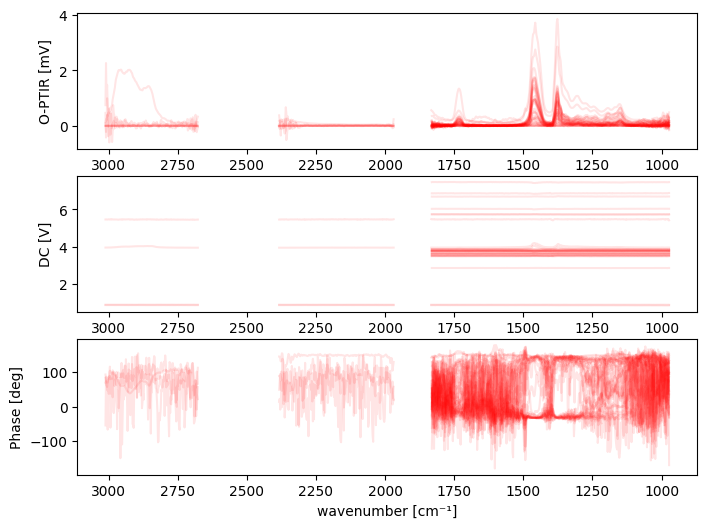

In [ ]:
fig = plt.figure(figsize=(8,6))
gs = fig.add_gridspec(len(channel_labels),1)

for icl,cl in enumerate(channel_labels.keys()):
    ax = fig.add_subplot(gs[icl])
    uuids = channel_labels[cl]

    for uuid in uuids:
        spectrum = PTIRFILE[uuid]
        ax.plot(spectrum.spectral_domain.to_array(), spectrum.data, color='r', alpha=0.1)

    ax.set_xlabel("wavenumber [cm⁻¹]")
    ax.set_ylabel(f"{cl} [{spectrum.optir_channel.unit}]")
    ax.invert_xaxis()

plt.show()
plt.close(fig)

### Identify Spectral Domains of spectrum-like measurements

In [ ]:

### find all unique spectroscopic domains
specdomains = set()
for measurement in PTIRFILE.all_measurements.values():
    if hasattr(measurement, "spectral_domain"):
        specdomains.add(measurement.spectral_domain)

infostring = f"{len(specdomains)} unique Spectral Measurement Domains:"
for sd in specdomains:
    infostring += f"\n- {sd}"
print(infostring)

3 unique Spectral Measurement Domains:
- <<class 'ptirtools.domains.EquidistantSpectralDomain'>, 973.0, 4.0, 510>
- <<class 'ptirtools.domains.EquidistantSpectralDomain'>, 973.0, 2.0, 1020>
- <<class 'ptirtools.domains.EquidistantSpectralDomain'>, 973.0, 2.0, 430>


In [ ]:
groups_of_matching_images = PTIRFILE.find_complementary_optir_images()
print( f"{len(groups_of_matching_images)} groups of matching images." )

AttributeError: 'PTIRFile' object has no attribute 'find_complementary_optir_images'